# Data Science and Analytics
## Business Sales Performance Analytics - Online Retail Dataset


**Goal:**  We want here to analyze a real sales dataset to understand business performance, identify trends, and provide actionable recommendations.

The dataset contains features  like invoices, products, customers, and countries).

**What We will deliver in this notebook**
- Data loading and cleaning
- Exploratory data analysis (EDA)
- Visualizations (matplotlib)
- Insights and recommendations

\
By ***Joachim SINYABE DANBE***

## 1. Setup
We work with:
- **pandas / numpy** for data wrangling
- **matplotlib** for charts


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Load the data

In [11]:
data = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
print("Shape:", data.shape)
data.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 3. Data cleaning
Typical issues in retail invoices:
- Missing `CustomerID` (cannot do customer-level metrics without it)
- Cancelled invoices (often `InvoiceNo` starts with `C`)
- Negative/zero `Quantity` or `UnitPrice` (returns, errors, or invalid rows)
- Dates as strings

**We used the following cleaning rule**
1. Parse `InvoiceDate` to datetime
2. Drop rows missing key fields
3. Keep rows with valid `CustomerID`
4. Remove cancelled invoices (`InvoiceNo` begins with `C`)
5. Keep only `Quantity > 0` and `UnitPrice > 0`
6. Create a `Revenue = Quantity × UnitPrice` column


In [4]:
df = data.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice", "Country"])

# We Keep rows with a valid CustomerID
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

# We Remove cancelled invoices (which  start with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# We Keep only positive quantity and price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# And the Revenue is: 
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
 
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


After removing the missing values, we are left with **397,884** valid observations (down from 541,909 raw rows). This means roughly 27% of the data was removed  mainly due to missing `CustomerID` values and cancelled or invalid transactions.


## 4. Business KPIs
We compute high-level metrics:
- Total revenue
- Number of invoices (orders)
- Number of unique customers
- Number of unique products
- Average order value (AOV = revenue / invoices)


In [5]:
total_revenue = df["Revenue"].sum()

num_invoices = df["InvoiceNo"].nunique()

num_customers = df["CustomerID"].nunique()

num_products = df["StockCode"].nunique()

avg_order_value = total_revenue / num_invoices

kpis = pd.DataFrame({
    "Metric": ["Total Revenue", "Invoices (Orders)", "Unique Customers", "Unique Products", "Average Order Value (AOV)"],
    "Value": [total_revenue, num_invoices, num_customers, num_products, avg_order_value]
})

kpis

,Metric,Value
0,Total Revenue,8.911408e+06
1,Invoices (Orders),1.853200e+04
2,Unique Customers,4.338000e+03
3,Unique Products,3.665000e+03
4,Average Order Value (AOV),4.808660e+02


## 5. Sales trends over time
We aggregate revenue by month to see seasonality and growth/decline.


In [12]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly = df.groupby("YearMonth", as_index=False)["Revenue"].sum()

monthly["YearMonth_dt"] = pd.to_datetime(monthly["YearMonth"] + "-01")

monthly = monthly.sort_values("YearMonth_dt")

monthly.head()


,YearMonth,Revenue,YearMonth_dt
0,2010-12,572713.890,2010-12-01
1,2011-01,569445.040,2011-01-01
2,2011-02,447137.350,2011-02-01
3,2011-03,595500.760,2011-03-01
4,2011-04,469200.361,2011-04-01


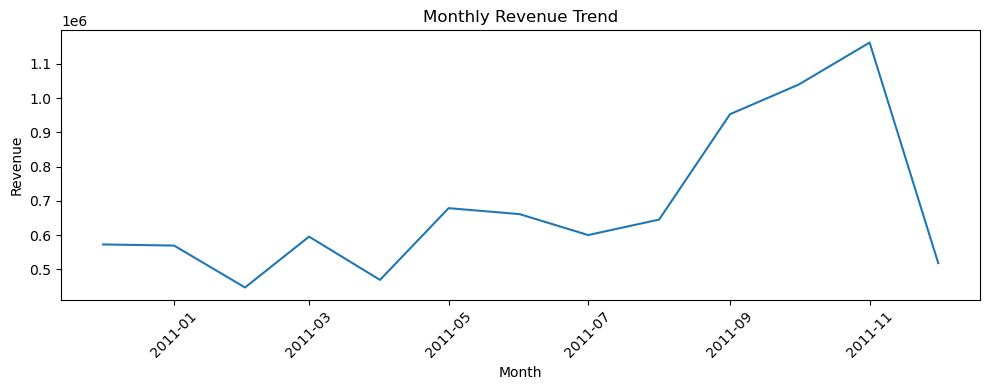

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["YearMonth_dt"], monthly["Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretation  Monthly Revenue Trend

- **Overall trend is upward**: Revenue grows from £572K in December 2010 to a sharp peak of **~£1.16M in November 2011**, indicating strong business growth over the year.
- **Seasonal peak in Q4 (Oct-Nov)**: Revenue spikes significantly in the last quarter of the year, consistent with holiday shopping behaviour (Christmas gift purchases). This is a classic retail seasonality pattern.
- **Dip in early 2011 (Feb -Apr)**: Revenue drops noticeably after the December peak, which is typical post-holiday slowdown. February 2011 is the weakest month at around ~£447K.
- **December 2011 data appears incomplete**: The sharp drop in December 2011 is likely due to the dataset being cut off mid-month, not a real decline. This should not be interpreted as a business downturn.
- **Business implication**: The company should plan inventory build-up and marketing campaigns **by September** to capitalise on the Q4 surge.

## 6. Top products
We identify the products generating the most revenue.


In [14]:
top_products = (
    df.groupby(["StockCode", "Description"], as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

top_products


,StockCode,Description,Revenue
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1318,22423,REGENCY CAKESTAND 3 TIER,142592.95
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3444,85099B,JUMBO BAG RED RETROSPOT,85220.78
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
3896,POST,POSTAGE,77803.96
2799,47566,PARTY BUNTING,68844.33
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56580.34
3894,M,Manual,53779.93
2006,23084,RABBIT NIGHT LIGHT,51346.20


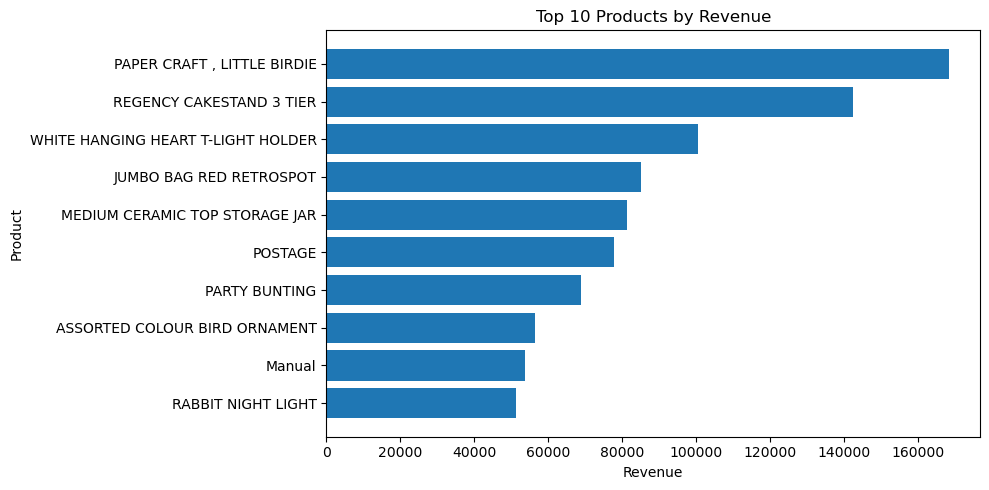

In [15]:
tp = top_products.sort_values("Revenue")

plt.figure(figsize=(10, 5))
plt.barh(tp["Description"].astype(str), tp["Revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


### Interpretation

- **PAPER CRAFT, LITTLE BIRDIE** leads with £168K in revenue. Given its relatively low unit price, this is driven by **very high sales volume**, making it a key volume product to keep well stocked.
- **REGENCY CAKESTAND 3 TIER** comes second at £143K. This is likely a higher-priced item, generating revenue through **value per unit** rather than sheer volume.
- **'POSTAGE' and 'Manual' are not real products** :  they are billing artefacts in the dataset. They should be **excluded from product-level analysis** to avoid distorting rankings. In a real client report, these rows would be filtered out during cleaning.
- The **top 3 products alone account for ~£411K**, which is roughly **4.6% of total revenue** : a significant concentration. Losing any of these products (stock-out, supplier issue) could have a measurable impact on total revenue.
- **Business implication**: Prioritise supply chain reliability for the top 5 products. Consider bundle offers pairing high-revenue items with slower-moving products to increase average basket size.


## 7. Revenue by country
We identify the countries generating the most revenue.


In [16]:
country_rev = (
    df.groupby("Country", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
)

country_rev.head(15)


,Country,Revenue
35,United Kingdom,7308391.554
23,Netherlands,285446.340
10,EIRE,265545.900
14,Germany,228867.140
13,France,209024.050
0,Australia,138521.310
30,Spain,61577.110
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38378.330


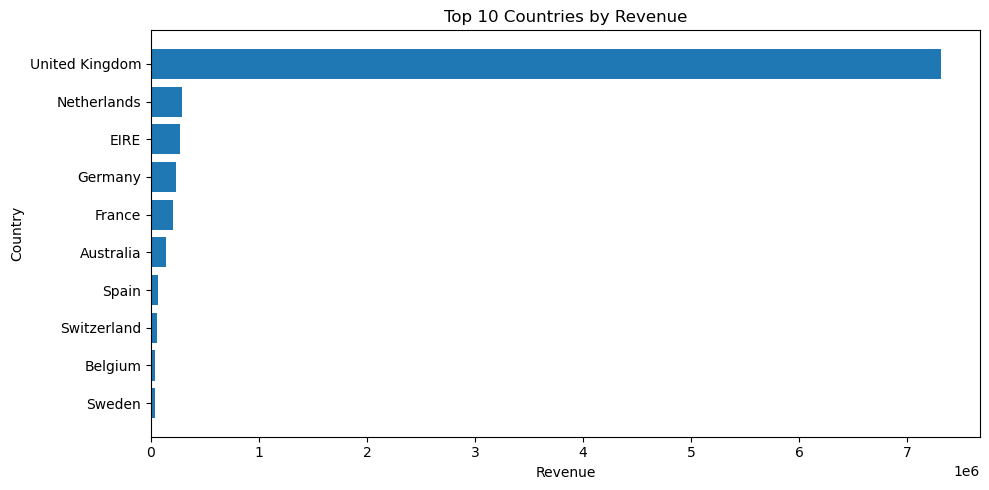

In [17]:
top_countries = country_rev.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 5))
plt.barh(top_countries["Country"], top_countries["Revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 8. Customer behavior
We check how many customers are repeat buyers and who the top customers are by revenue.


In [18]:
cust_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_rate = (cust_orders > 1).mean()

top_customers = (
    df.groupby("CustomerID", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

repeat_rate, top_customers


(0.6558321807284463,
       CustomerID    Revenue
 1689       14646  280206.02
 4201       18102  259657.30
 3728       17450  194550.79
 3008       16446  168472.50
 1879       14911  143825.06
 55         12415  124914.53
 1333       14156  117379.63
 3771       17511   91062.38
 2702       16029   81024.84
 0          12346   77183.60)

###  Interpretation 

**Repeat purchase rate (65.6%):**
- Nearly **2 out of 3 customers** place more than one order, which is a strong retention signal for an e-commerce business. Industry benchmarks typically consider anything above 40–50% as healthy for online retail.
- However, 34.4% of customers only buy once  this **one-time buyer segment** is an opportunity. A targeted re-engagement campaign (email follow-up, discount on second order) could meaningfully improve lifetime value.

**About customers:**
- Customer **14646** alone generates **£280K** - about 3.1% of total revenue from a single customer. The top 10 customers together likely account for a significant share of total revenue.
- This level of concentration is a **business risk**: losing one or two key accounts could have an outsized impact. A key account management or VIP programme should be in place for these customers.
- **Business implication**: Focus retention efforts on the top 20% of customers by revenue while running reactivation campaigns for the one-time buyers.


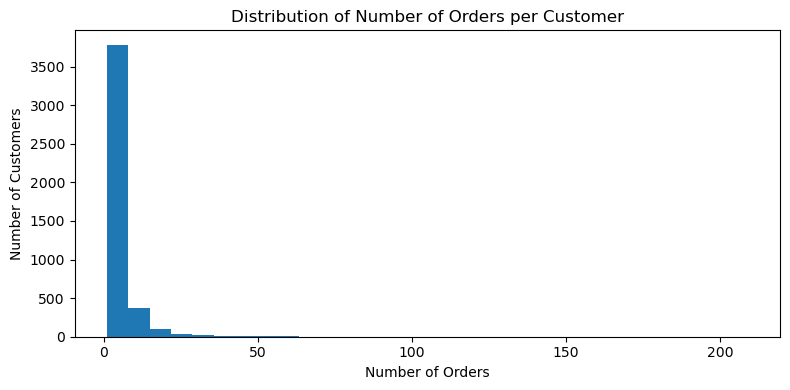

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(cust_orders, bins=30)
plt.title("Distribution of Number of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


- The distribution is **heavily right-skewed**: the vast majority of customers place between 1 and 5 orders, while a small group of loyal customers place 20+ orders.
- This is a classic **Pareto-style pattern** in retail: a small number of highly loyal customers drive a disproportionate share of transactions.

## 9. Summary Insights and Strategic Recommendations

### Key Business Findings

| Metric | Value |
|--------|-------|
| **Total Revenue** | £8,911,408 |
| **Total Orders** | 18,532 |
| **Unique Customers** | 4,338 |
| **Unique Products** | 3,665 |
| **Average Order Value (AOV)** | £480.87 |
| **Peak Revenue Month** | November 2011 - £1,161,817 |
| **Lowest Revenue Month** | February 2011 - £447,137 |
| **Repeat Customer Rate** | 65.6% |

> This dataset covers transactions from December 2010 to December 2011. All insights are based on this historical window. December 2011 data appears to be incomplete (mid-month cut-off) and should not be interpreted as a business decline.

---

###  Recommendations

**1. Prepare for the Q4 seasonal peak (highest priority)**
Revenue nearly doubles between August and November. The business should begin inventory build-up and marketing campaigns in **September at the latest**. Fulfillment capacity should be reviewed ahead of this window to avoid stock-outs on top-selling products.

**2. Protect and grow the top product lines**
The top 5 products (excluding POSTAGE/Manual artefacts) contribute a disproportionate share of revenue. Ensure consistent stock availability, negotiate supply agreements, and test bundle pricing strategies to increase basket size around these hero products.

**3. Reduce geographic concentration risk**
The UK represents 82% of revenue. Germany, France and the Netherlands already show meaningful traction and are logistically accessible. A focused digital marketing push in these markets could diversify revenue and reduce single-market dependency.

**4. Launch a customer retention and reactivation programme**
With 65.6% repeat rate, the business already has strong loyalty foundations. Two actions are recommended:
- **VIP programme** for the top 50-100 customers by revenue (they carry outsized revenue risk if lost)
- **Re-engagement campaign** for the ~34% one-time buyers: a personalised email with a discount code within 30 days of first purchase could convert a meaningful share into repeat buyers.

**5. Clean up non-product entries in the catalog**
Entries like 'POSTAGE' and 'Manual' should be excluded from product analytics. A clean product taxonomy will improve the reliability of all future product-level reporting.

> *These insights are based on descriptive analytics of historical transaction data. For demand forecasting or predictive modelling, time-series methods (e.g. ARIMA, Prophet) would be the appropriate next step, using time-based train/test splits to avoid data leakage.*
